## OOI Lab Manual 2025: Lab 12 Forest Fires

This notebook demonstrates how to access and process the dataset used in *Lab 12 Forest Fires* in the 2025 edition of the *OOI Lab Manual*.

By Sage Lichtenwalner, Rutgers University

Revised: December 10, 2024

In [1]:
# Notebook Setup
from erddapy import ERDDAP
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set()

For this lab, we will pull the following datasets for the time period around the Oregon Fires, September 4-30, 2020.

* Oregon Shelf Surface Mooring (ooi-ce02shsm-sbd11-06-metbka000)
  * Humidity
  * Air Temperature
  * Eastward Winds & Wind Speed
  * Shortwave Radiation
* Oregon Offshore Surface Mooring (ooi-ce04ossm - various)
  * Backscatter
  * CDOM
  * Chlorophyll
  * Oxygen

In [2]:
# Setup a connection to the OOI ERDDAP server
server = "https://erddap.dataexplorer.oceanobservatories.org/erddap/"
e = ERDDAP(
    server=server,
    protocol="tabledap",
    response="csv",
)

## Activity 1 - Oregon Shelf Surface Mooring

In [3]:
url_ce02shsm = e.get_download_url(
  dataset_id='ooi-ce02shsm-sbd11-06-metbka000',
  variables=['time', 'relative_humidity', 'air_temperature', 'eastward_wind', 'northward_wind','netsirr','sea_surface_temperature'],
  constraints={"time>=": "2020-09-01", "time<=": "2020-10-01"}
)
df_url_ce02shsm = pd.read_csv(url_ce02shsm, index_col='time', parse_dates=True, skiprows=[1])
df_url_ce02shsm = df_url_ce02shsm.resample('1h').mean()

# Calculate wind speed and direction
df_url_ce02shsm['wind_speed'] = np.sqrt(df_url_ce02shsm['eastward_wind']**2 + df_url_ce02shsm['northward_wind']**2)
df_url_ce02shsm['wind_direction'] = np.arctan2(df_url_ce02shsm['eastward_wind'], df_url_ce02shsm['northward_wind']) * (180 / np.pi)
df_url_ce02shsm['wind_direction360'] = (df_url_ce02shsm['wind_direction'] + 360) % 360

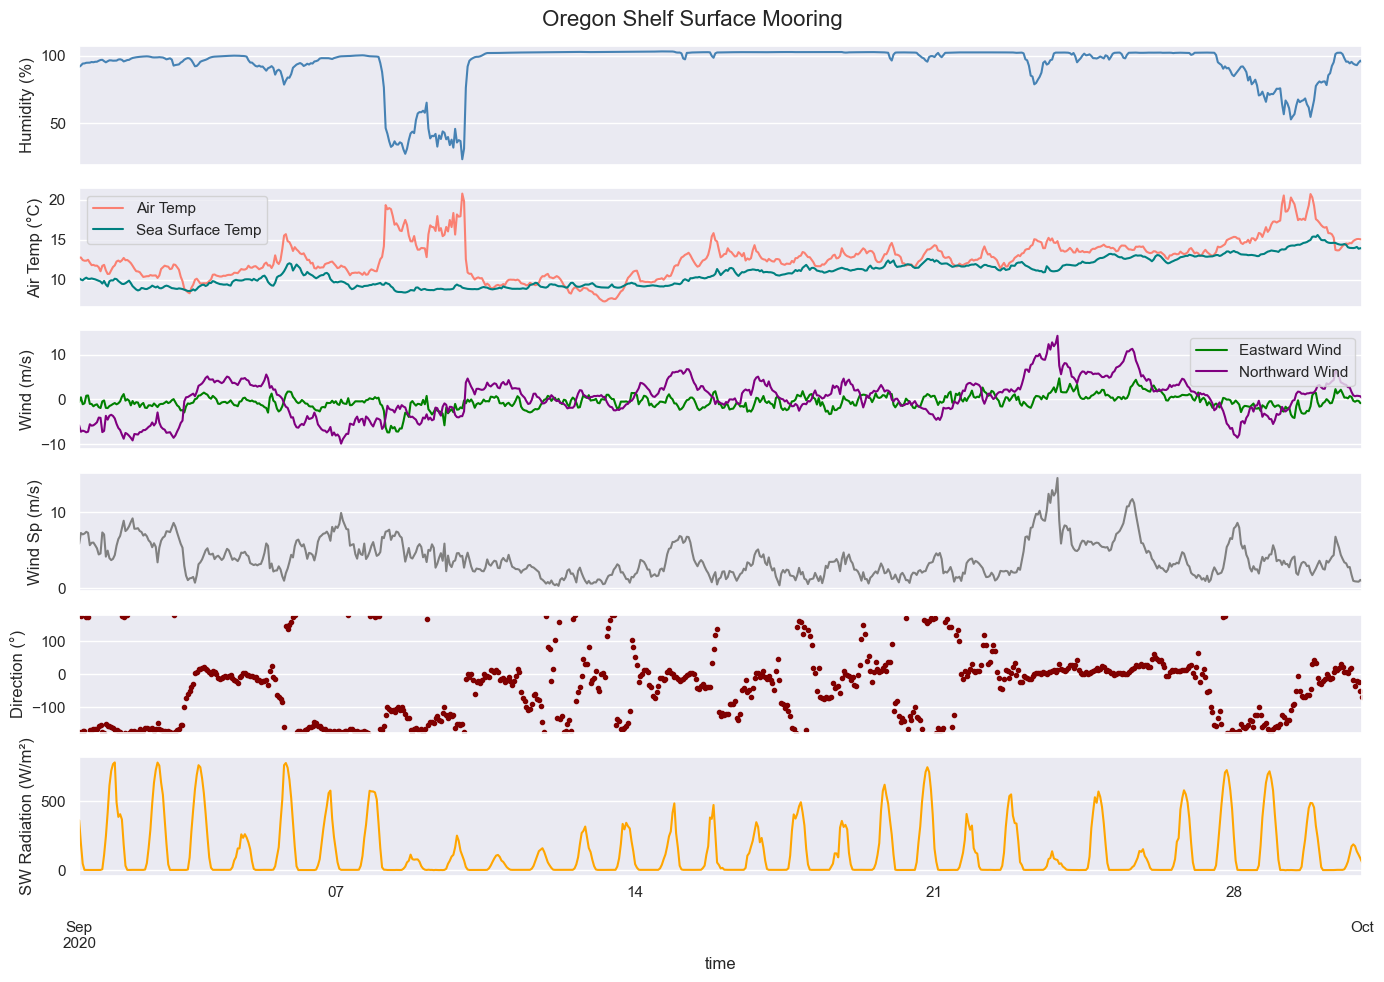

In [23]:
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(14, 10), sharex=True)

df_url_ce02shsm['relative_humidity'].plot(ax=axes[0], color='steelblue')
axes[0].set_ylabel('Humidity (%)')

df_url_ce02shsm['air_temperature'].plot(ax=axes[1], color = 'salmon', label='Air Temp')
df_url_ce02shsm['sea_surface_temperature'].plot(ax=axes[1], color = 'teal', label='Sea Surface Temp')
axes[1].set_ylabel('Air Temp (°C)')
axes[1].legend()

df_url_ce02shsm['eastward_wind'].plot(ax=axes[2], color = 'green', label='Eastward Wind')
df_url_ce02shsm['northward_wind'].plot(ax=axes[2], color='purple', label='Northward Wind')
axes[2].set_ylabel('Wind (m/s)')
axes[2].legend()

df_url_ce02shsm['wind_speed'].plot(ax=axes[3], color = 'grey')
axes[3].set_ylabel('Wind Sp (m/s)')

df_url_ce02shsm['wind_direction'].plot(ax=axes[4], color = 'maroon', linestyle='', marker='.') 
axes[4].set_ylabel('Direction (°)')
axes[4].set_ylim(-180, 180)

df_url_ce02shsm['netsirr'].plot(ax=axes[5], color = 'orange')
axes[5].set_ylabel('SW Radiation (W/m²)')

fig.suptitle('Oregon Shelf Surface Mooring', fontsize=16)
fig.tight_layout()

In [16]:
# Save to CSV 
# df_url_ce02shsm.to_csv('data/lab12_ce02shsm.csv', date_format='%Y-%m-%d %H:%M', float_format='%.3f')

## Activity 2 - Oregon Offshore Surface Mooring

In [4]:
# Load the FLORT data
url_ce04flort = e.get_download_url(
  dataset_id='ooi-ce04ossm-rid27-02-flortd000',
  variables=['time', 'cdomflo', 'mass_concentration_of_chlorophyll_a_in_sea_water', 'flubsct'],
  constraints={"time>=": "2020-09-01", "time<=": "2020-10-01"}
)
df_ce04flort = pd.read_csv(url_ce04flort, index_col='time', parse_dates=True, skiprows=[1])
df_ce04flort = df_ce04flort.resample('1h').mean()

# Load the Oxygen data
url_ce04dosta = e.get_download_url(
  dataset_id='ooi-ce04ossm-rid27-04-dostad000',
  variables=['time', 'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water'],
  constraints={"time>=": "2020-09-01", "time<=": "2020-10-01"}
)
df_ce04dosta = pd.read_csv(url_ce04dosta, index_col='time', parse_dates=True, skiprows=[1])
df_ce04dosta = df_ce04dosta.resample('1h').mean()

# Load the Nitrate data
url_ce04nutnr = e.get_download_url(
  dataset_id='ooi-ce04ossm-rid26-07-nutnrb000',
  variables=['time', 'mole_concentration_of_nitrate_in_sea_water_suna'],
  constraints={"time>=": "2020-09-01", "time<=": "2020-10-01"}
)
df_ce04nutnr = pd.read_csv(url_ce04nutnr, index_col='time', parse_dates=True, skiprows=[1])
df_ce04nutnr = df_ce04nutnr.resample('1h').mean()

# Merge the averaged datasets together into one dataframe
df_merged = pd.concat([df_ce04flort, df_ce04dosta, df_ce04nutnr], axis=1)

# Display the merged dataframe
# df_merged.head()

HTTPError: HTTP Error 400: 

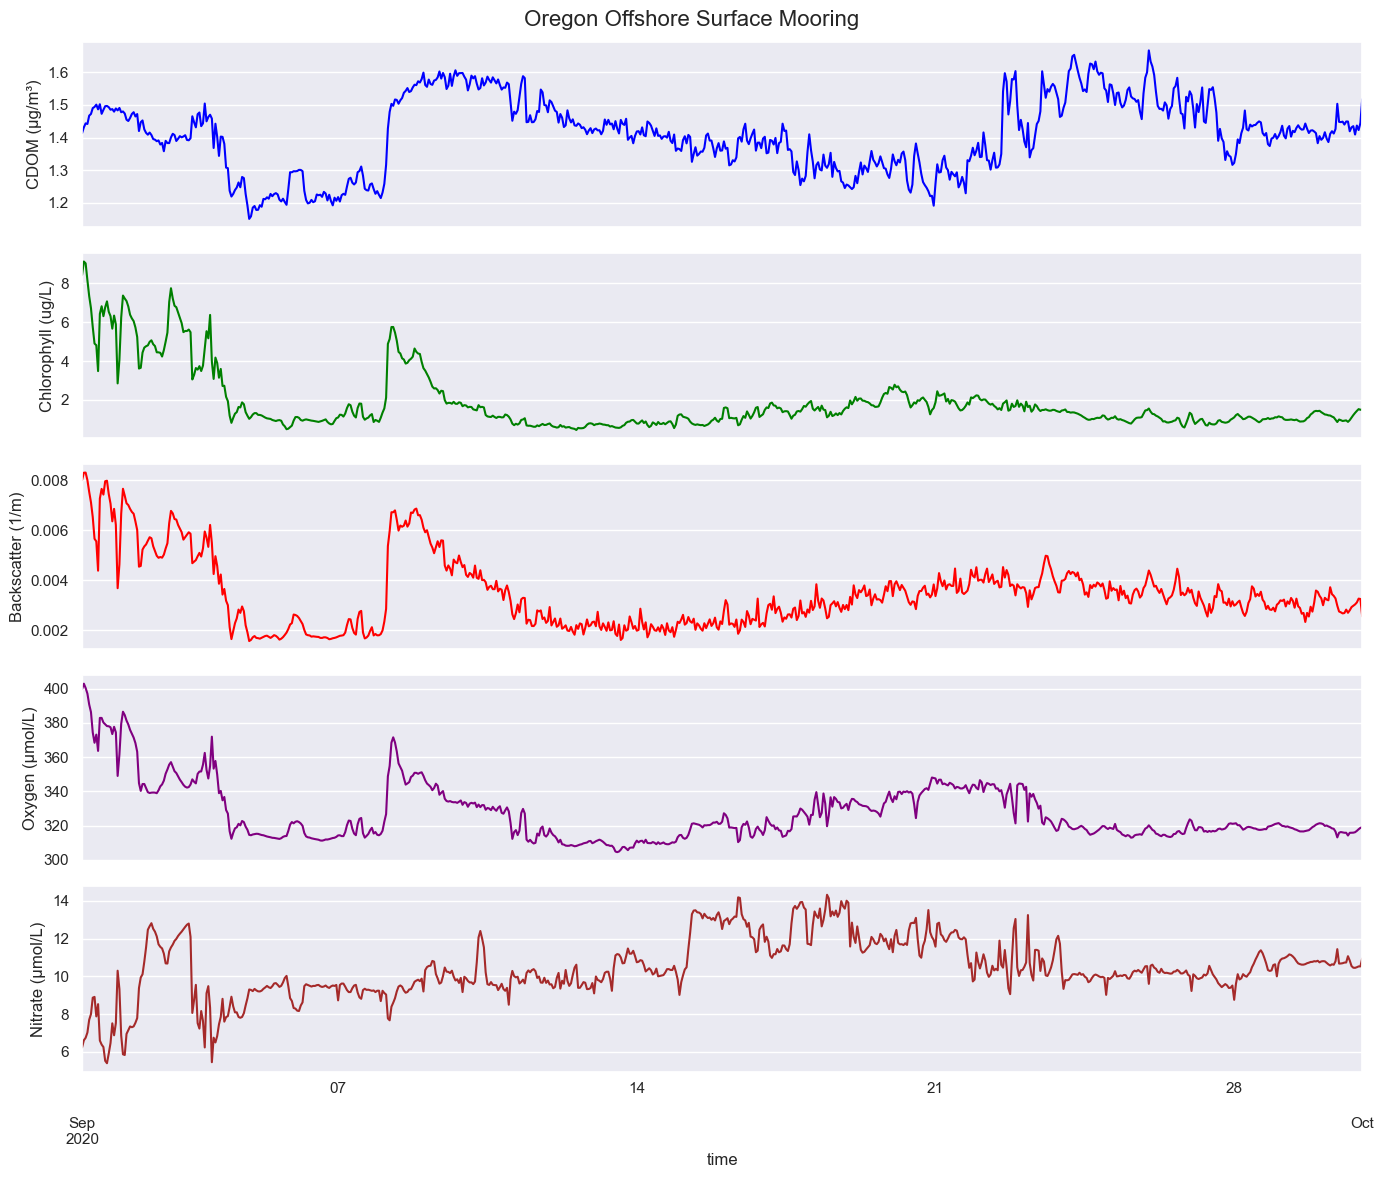

In [18]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)

df_merged['cdomflo'].plot(ax=axes[0], color='blue')
axes[0].set_ylabel('CDOM (µg/m³)')

df_merged['mass_concentration_of_chlorophyll_a_in_sea_water'].plot(ax=axes[1], color='green')
axes[1].set_ylabel('Chlorophyll (ug/L)')

df_merged['flubsct'].plot(ax=axes[2], color='red')
axes[2].set_ylabel('Backscatter (1/m)')

df_merged['mole_concentration_of_dissolved_molecular_oxygen_in_sea_water'].plot(ax=axes[3], color='purple')
axes[3].set_ylabel('Oxygen (µmol/L)')

df_merged['mole_concentration_of_nitrate_in_sea_water_suna'].plot(ax=axes[4], color='brown')
axes[4].set_ylabel('Nitrate (µmol/L)')
# axes[4].set_xlabel('Time')

fig.suptitle('Oregon Offshore Surface Mooring', fontsize=16)
fig.tight_layout()
plt.show()

In [19]:
# Save to CSV
# df_merged.to_csv('data/lab12_ce04ossm.csv', date_format='%Y-%m-%d %H:%M', float_format='%.4f')

## Activity 3 - Comparing Data
We need to create a combined dataset with winds, backscatter and CDOM.

In [25]:
# Merge df_url_ce02shsm and df_merged on their indices
df_combined = pd.merge(df_url_ce02shsm, df_merged, left_index=True, right_index=True, how='outer')

# Subset the dataframe to include only winds, CDOM, and Backscatter
df_combined = df_combined[[
    'eastward_wind', 'cdomflo', 'flubsct', 'netsirr', 'sea_surface_temperature', 'air_temperature',
]]

# Save to CSV
df_combined.to_csv('data/lab12_ce_combined.csv', date_format='%Y-%m-%d %H:%M', float_format='%.4f')

# Display the merged dataframe
# df_combined.head()

## Comparing Values
Let's compare a few variables.

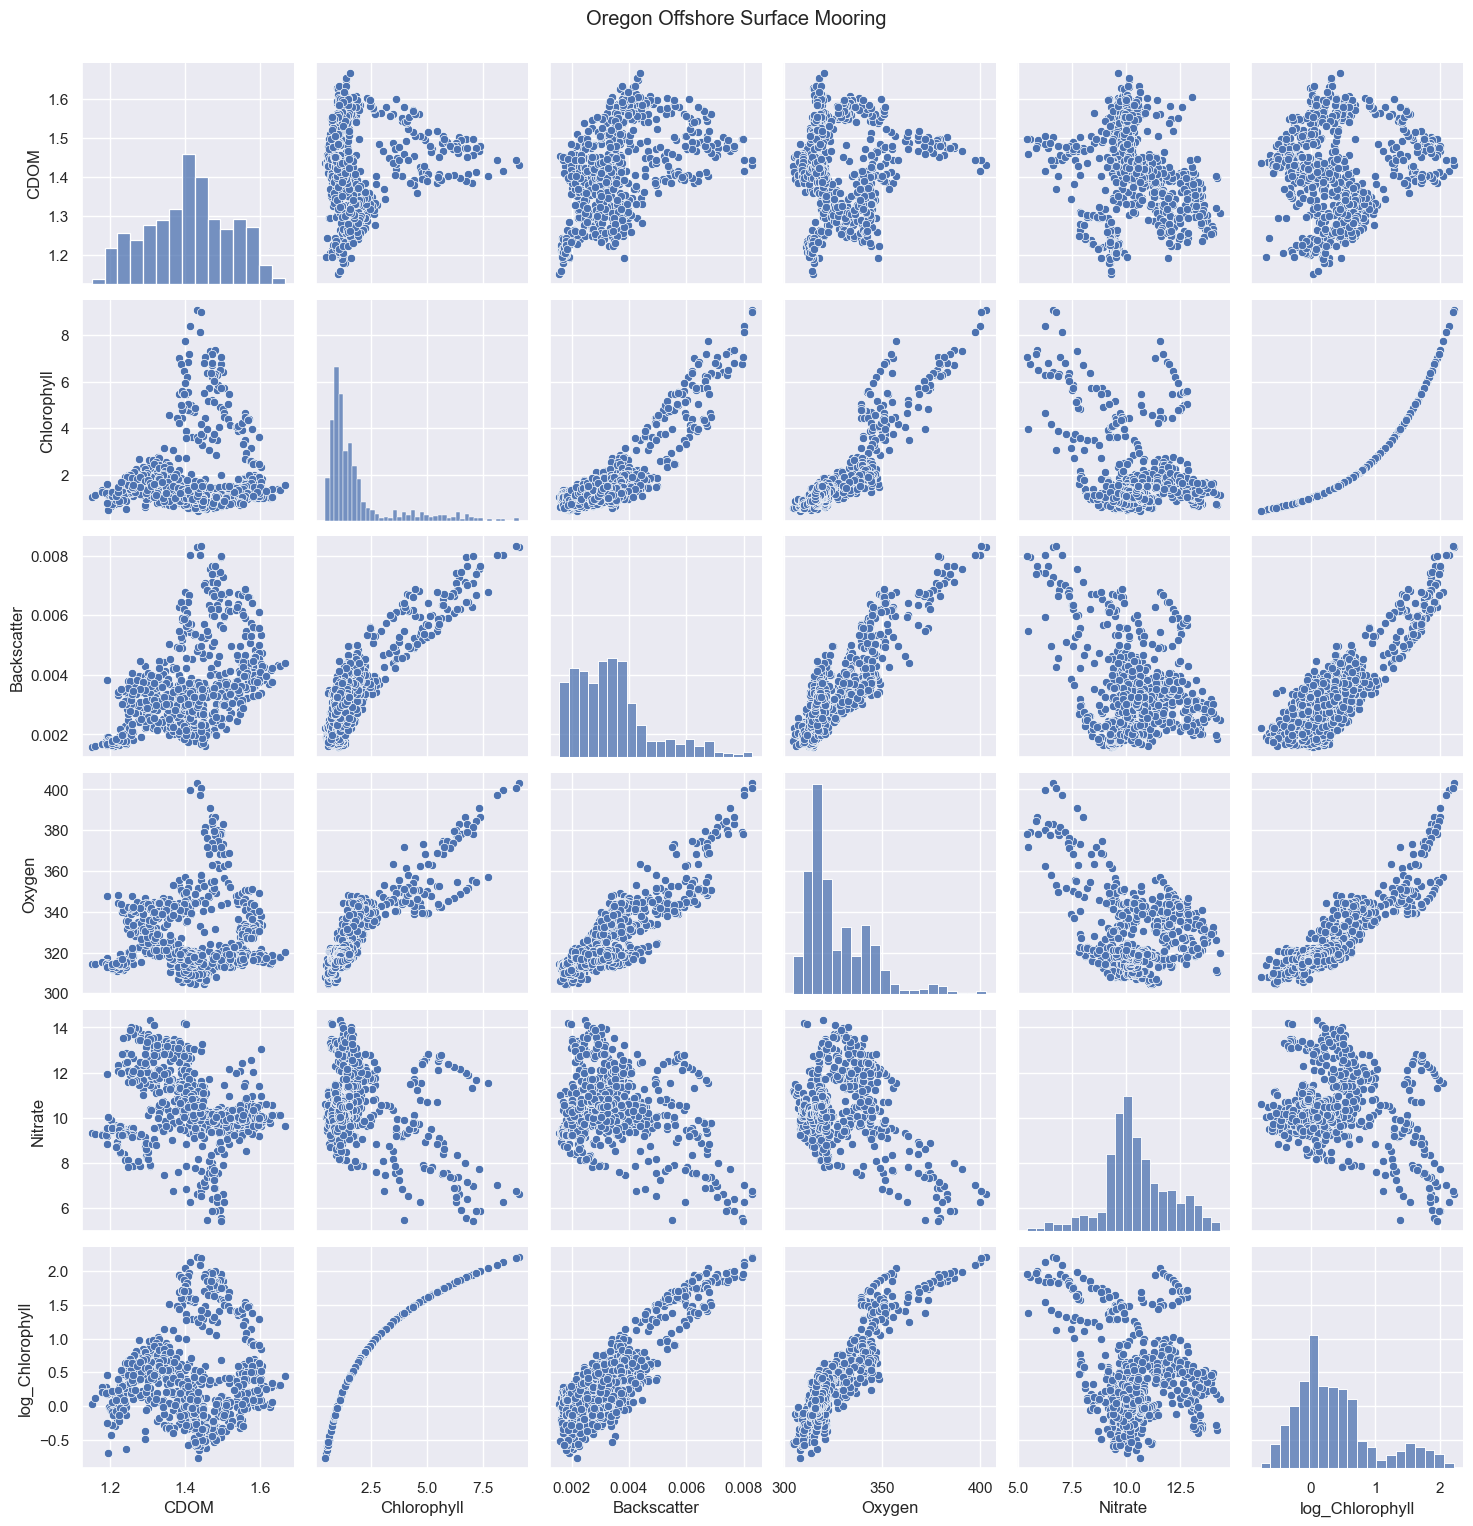

In [17]:
df_merged = df_merged.rename(columns={
    'cdomflo': 'CDOM',
    'mass_concentration_of_chlorophyll_a_in_sea_water': 'Chlorophyll',
    'flubsct': 'Backscatter',
    'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water': 'Oxygen',
    'mole_concentration_of_nitrate_in_sea_water_suna': 'Nitrate'
})
df_merged['log_Chlorophyll'] = np.log(df_merged['Chlorophyll'])

sns.pairplot(df_merged)
plt.suptitle('Oregon Offshore Surface Mooring', y=1.02)
plt.savefig('data/lab12_ce04ossm_pairplot.png')
plt.show()


## Additional Moorings
We use two different moorings above.  Let's look at all 3 Oregon moorings for both surface meteorology and underwater.

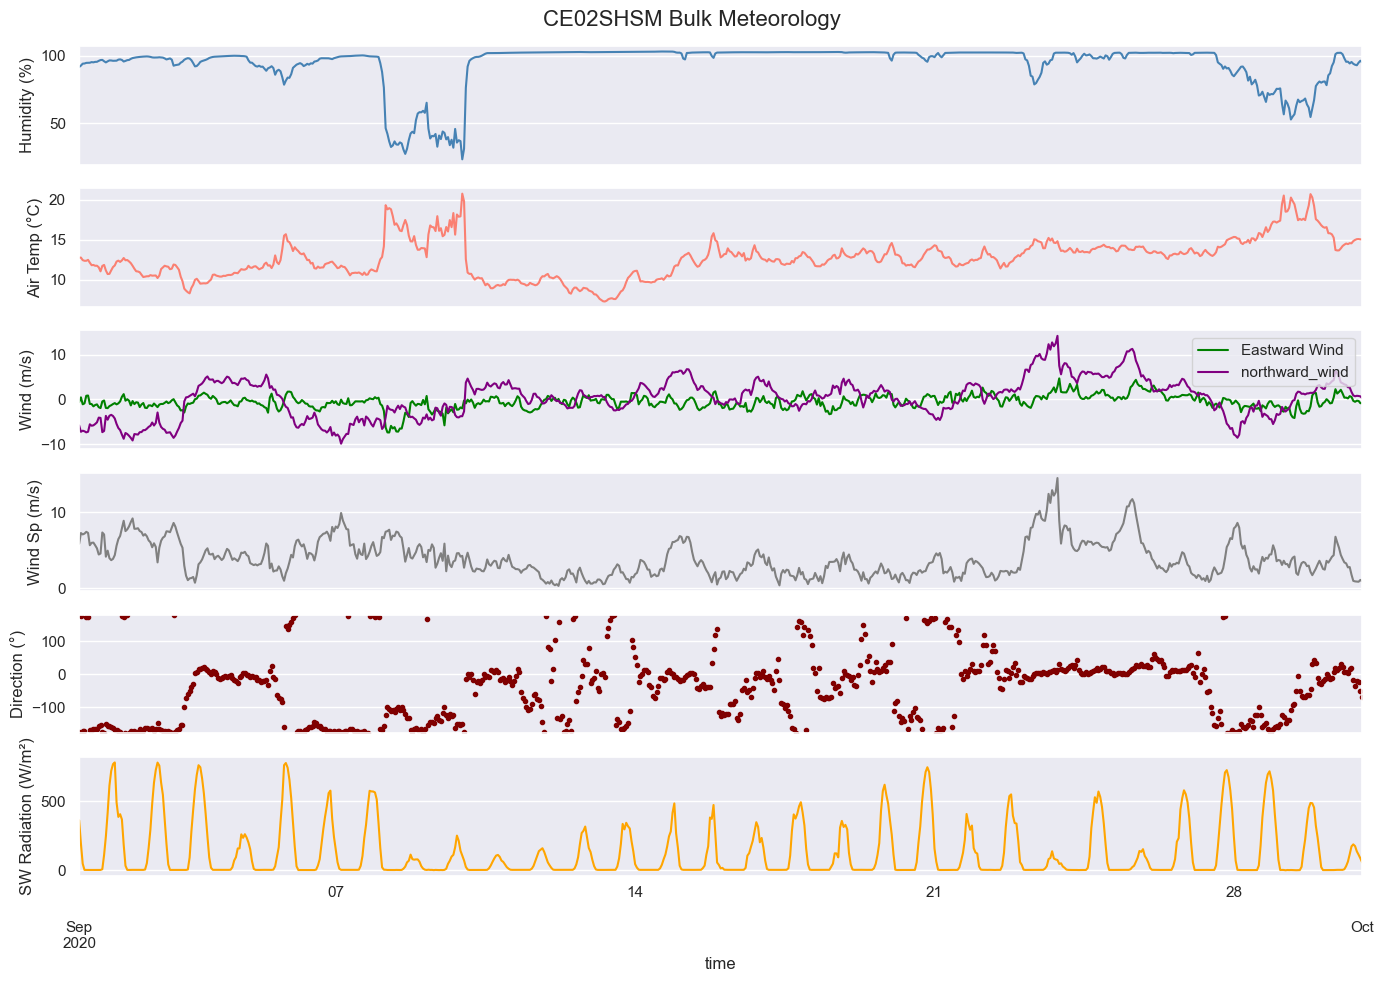

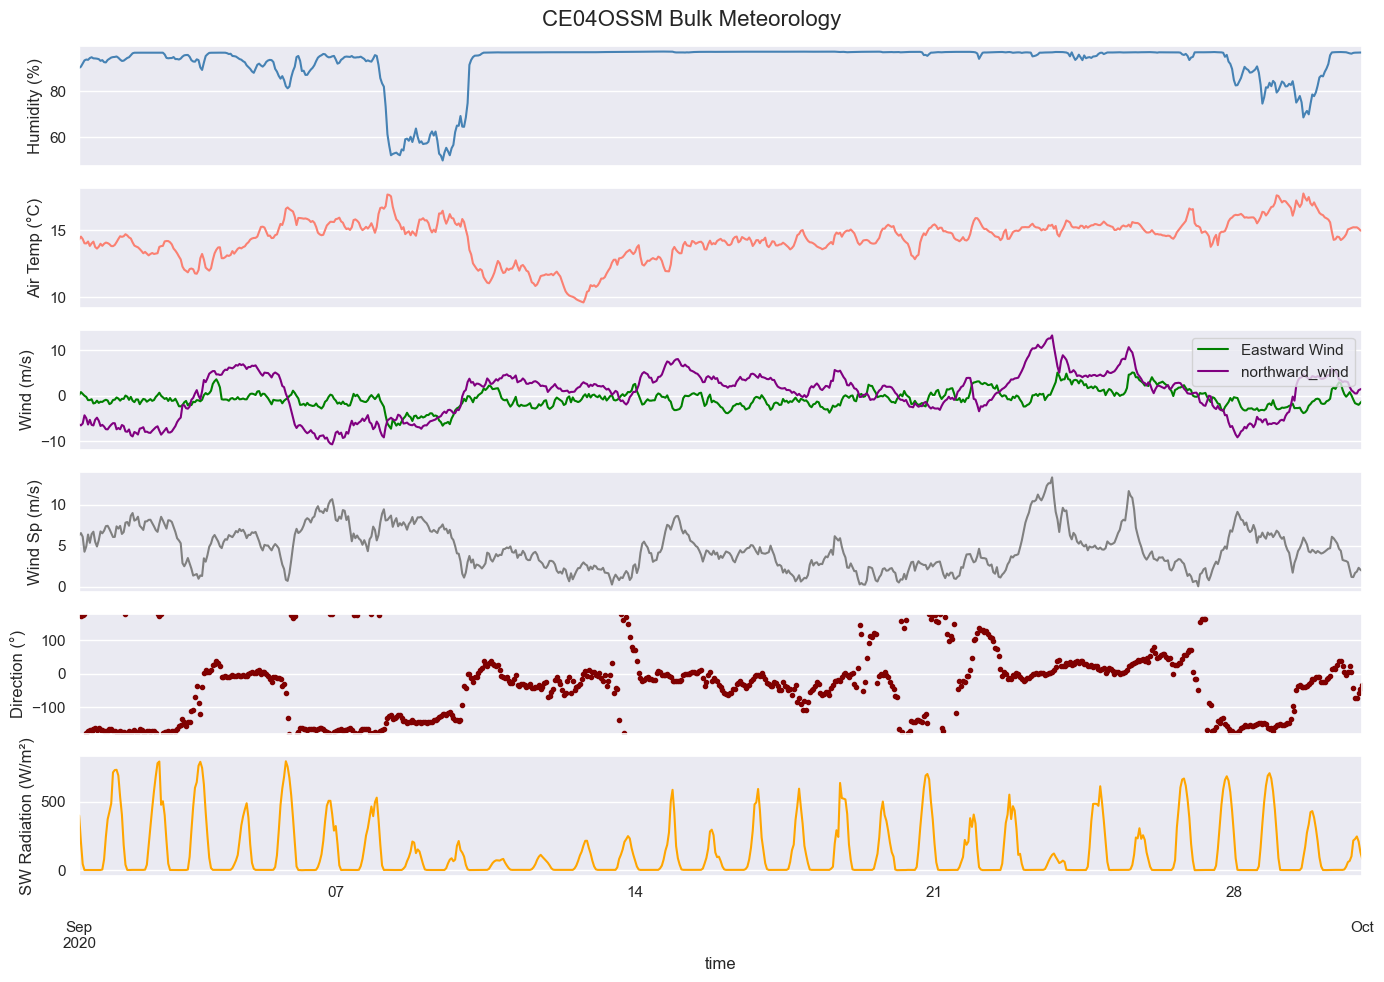

In [ ]:
# Surface Meteorology for the 2 offshore Oregon moorings (Inshore doesn't have met data)
for mooring in ['ce02shsm', 'ce04ossm']:

  url_met = e.get_download_url(
    dataset_id='ooi-%s-sbd11-06-metbka000' % mooring,
    variables=['time', 'relative_humidity', 'air_temperature', 'eastward_wind', 'northward_wind','netsirr'],
    constraints={"time>=": "2020-09-01", "time<=": "2020-10-01"}
  )
  df_met = pd.read_csv(url_met, index_col='time', parse_dates=True, skiprows=[1])
  df_met = df_met.resample('1h').mean()

  # Calculate wind speed and direction
  df_met['wind_speed'] = np.sqrt(df_met['eastward_wind']**2 + df_met['northward_wind']**2)
  df_met['wind_direction'] = np.arctan2(df_met['eastward_wind'], df_met['northward_wind']) * (180 / np.pi)

  fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(14, 10), sharex=True)

  df_met['relative_humidity'].plot(ax=axes[0], color='steelblue')
  axes[0].set_ylabel('Humidity (%)')

  df_met['air_temperature'].plot(ax=axes[1], color = 'salmon')
  axes[1].set_ylabel('Air Temp (°C)')

  df_met['eastward_wind'].plot(ax=axes[2], color = 'green', label='Eastward Wind')
  df_met['northward_wind'].plot(ax=axes[2], color='purple', layout='Northward Wind')
  axes[2].set_ylabel('Wind (m/s)')
  ax2 = axes[2].legend(loc='upper right')

  df_met['wind_speed'].plot(ax=axes[3], color = 'grey')
  axes[3].set_ylabel('Wind Sp (m/s)')

  df_met['wind_direction'].plot(ax=axes[4], color = 'maroon', linestyle='', marker='.') 
  axes[4].set_ylabel('Direction (°)')
  axes[4].set_ylim(-180, 180)

  df_met['netsirr'].plot(ax=axes[5], color = 'orange')
  axes[5].set_ylabel('SW Radiation (W/m²)')

  fig.suptitle(mooring.upper() + " Bulk Meteorology", fontsize=16)
  fig.tight_layout()
  plt.savefig(f'{mooring}_met.png', dpi=300, bbox_inches='tight')


https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap/ooi-ce04ossm-rid26-07-nutnrb000.csv?time,mole_concentration_of_nitrate_in_sea_water_suna&time>=1598918400.0&time<=1601510400.0
https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap/ooi-ce02shsm-rid26-07-nutnrb000.csv?time,mole_concentration_of_nitrate_in_sea_water_suna&time>=1598918400.0&time<=1601510400.0
https://erddap.dataexplorer.oceanobservatories.org/erddap/tabledap/ooi-ce01issm-rid16-07-nutnrb000.csv?time,mole_concentration_of_nitrate_in_sea_water_suna&time>=1598918400.0&time<=1601510400.0


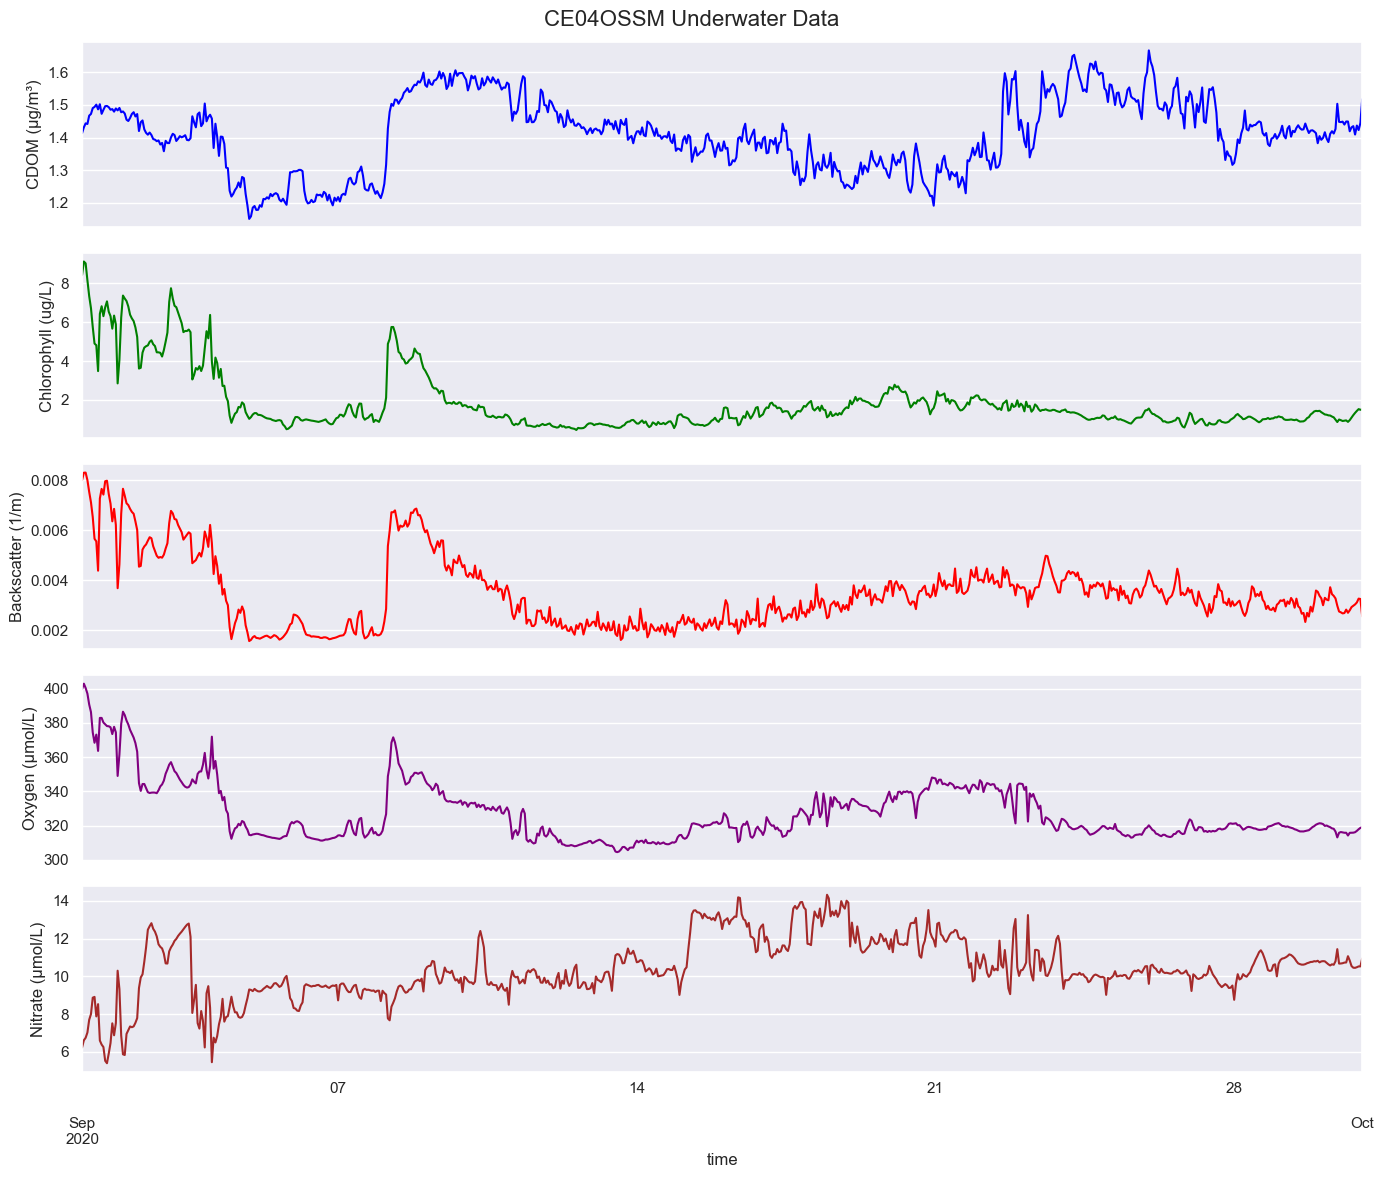

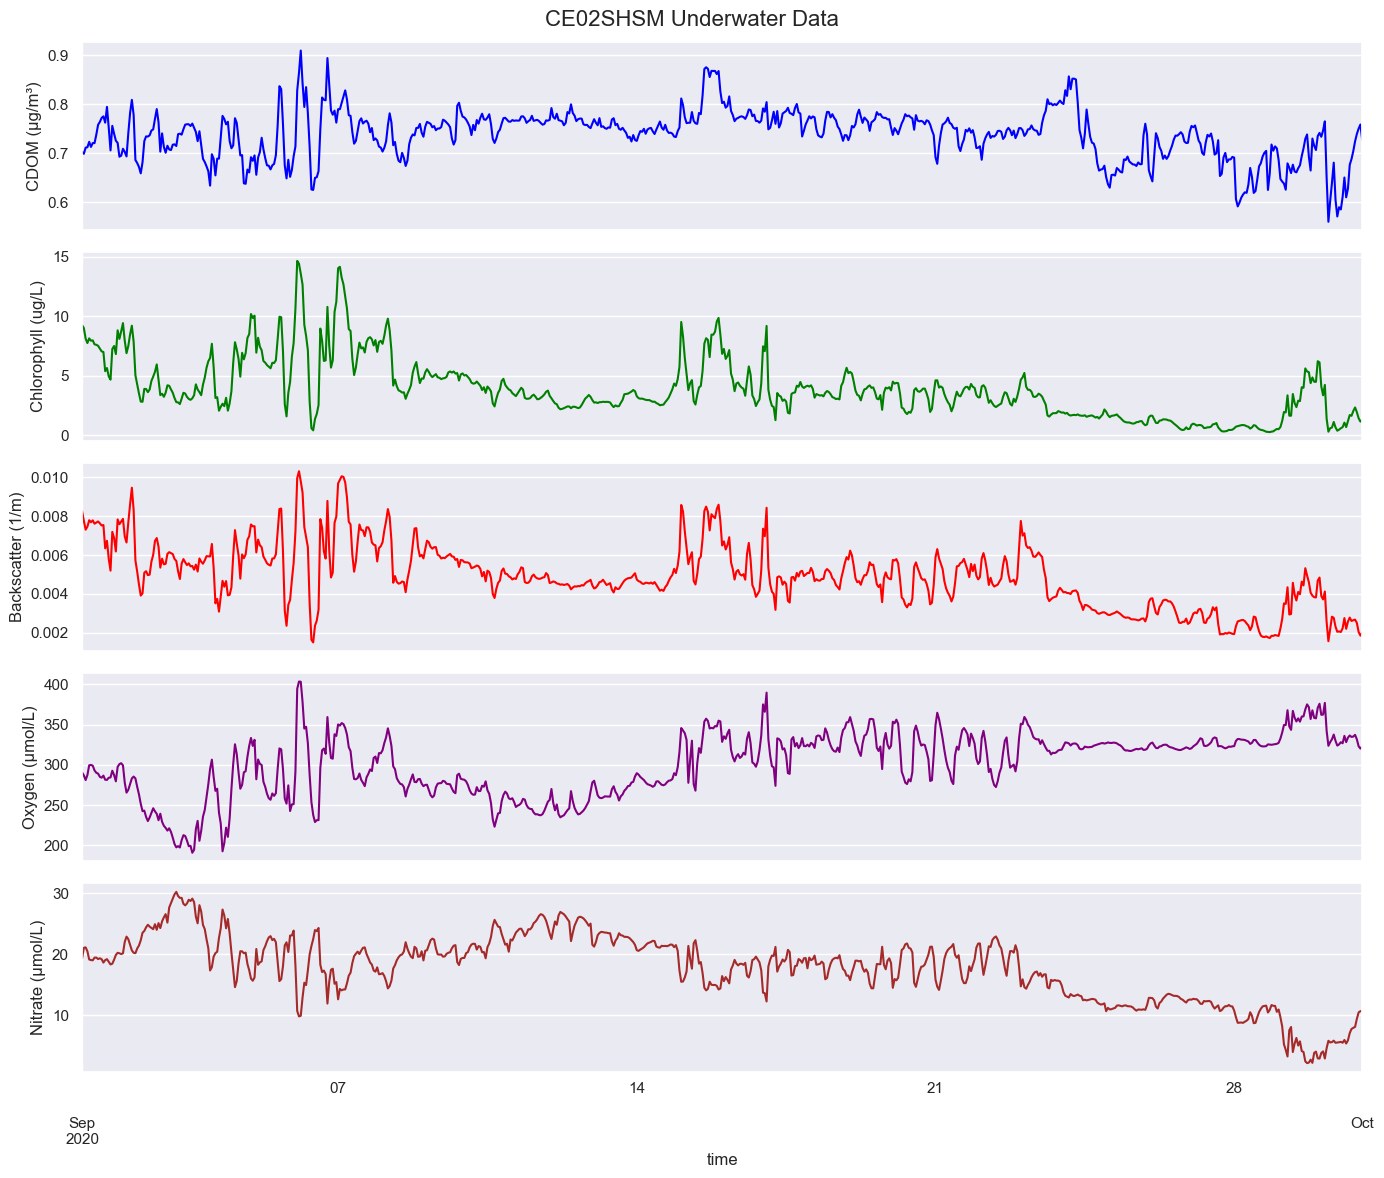

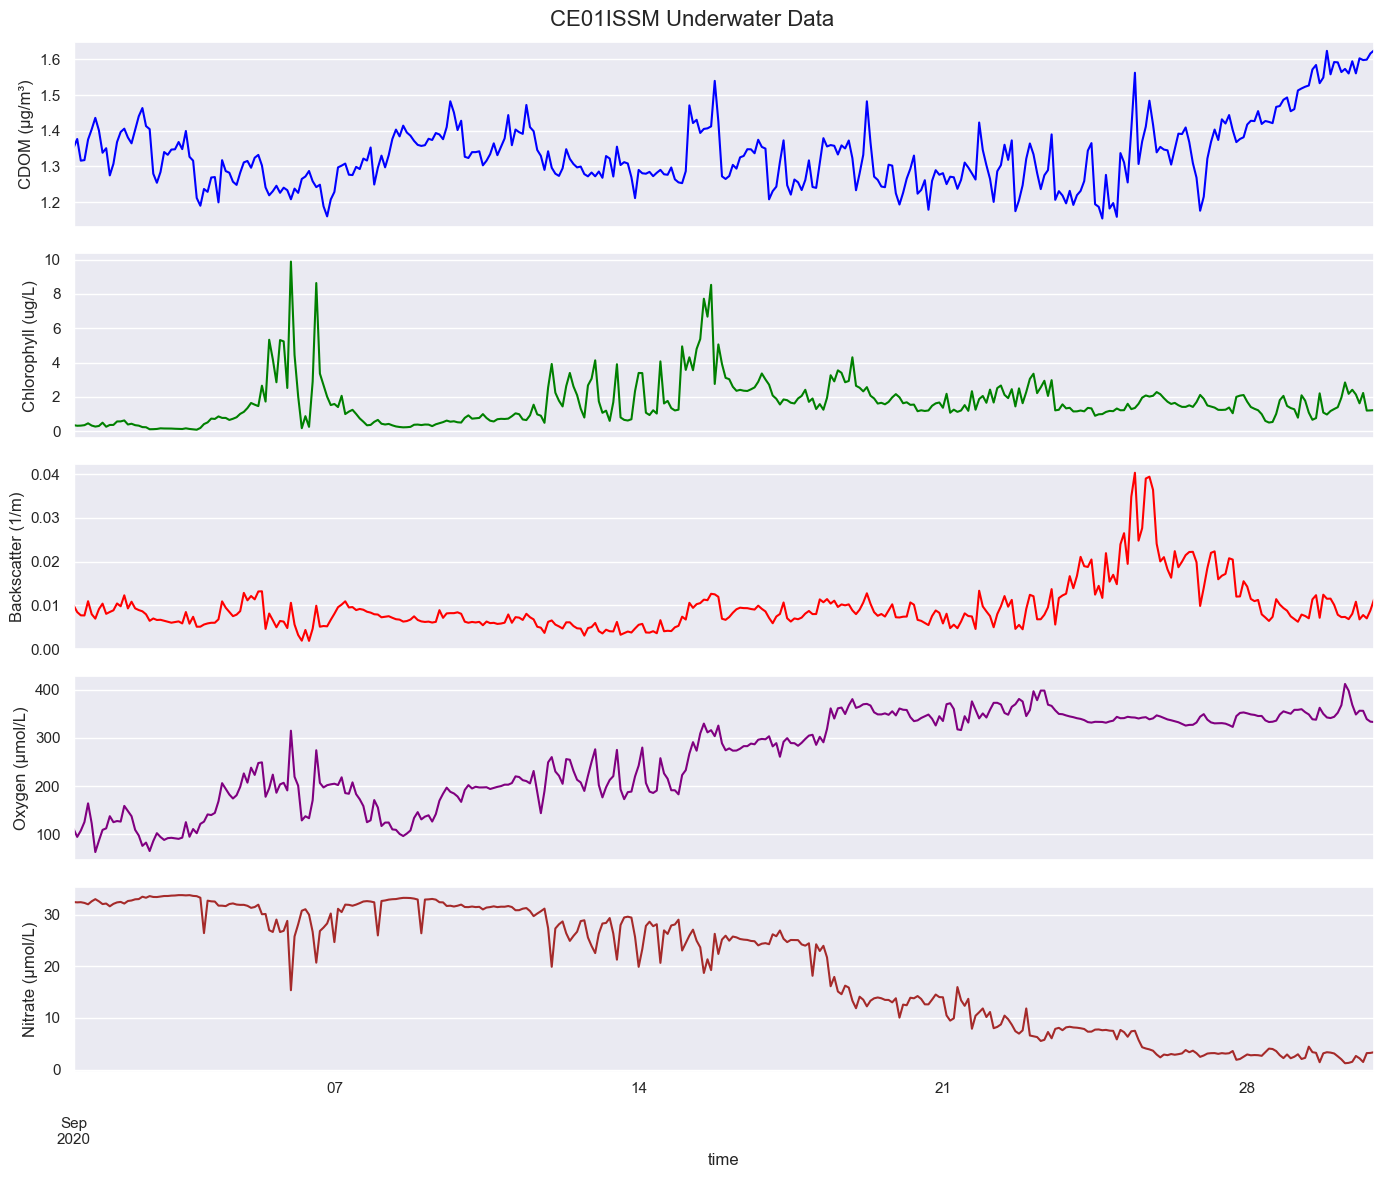

In [ ]:
# Underwater data for the three Oregon moorings
for mooring in ['ce04ossm', 'ce02shsm', 'ce01issm']:
  # Load the FLORT data
  url_flort = e.get_download_url(
    dataset_id = 'ooi-ce01issm-rid16-02-flortd000' if mooring == 'ce01issm' else f'ooi-{mooring}-rid27-02-flortd000',
    variables=['time', 'cdomflo', 'mass_concentration_of_chlorophyll_a_in_sea_water', 'flubsct'],
    constraints={"time>=": "2020-09-01", "time<=": "2020-10-01"}
  )
  df_flort = pd.read_csv(url_flort, index_col='time', parse_dates=True, skiprows=[1])
  df_flort = df_flort.resample('1h').mean()

  # Load the Oxygen data
  url_dosta = e.get_download_url(
    dataset_id = 'ooi-ce01issm-rid16-03-dostad000' if mooring == 'ce01issm' else f'ooi-{mooring}-rid27-04-dostad000',
    variables=['time', 'mole_concentration_of_dissolved_molecular_oxygen_in_sea_water'],
    constraints={"time>=": "2020-09-01", "time<=": "2020-10-01"}
  )
  df_dosta = pd.read_csv(url_dosta, index_col='time', parse_dates=True, skiprows=[1])
  df_dosta = df_dosta.resample('1h').mean()

  # Load the Nitrate data
  url_nutnr = e.get_download_url(
    dataset_id = 'ooi-ce01issm-rid16-07-nutnrb000' if mooring == 'ce01issm' else f'ooi-{mooring}-rid26-07-nutnrb000',
    variables=['time', 'mole_concentration_of_nitrate_in_sea_water_suna'],
    constraints={"time>=": "2020-09-01", "time<=": "2020-10-01"}
  )
  print(url_nutnr)
  df_nutnr = pd.read_csv(url_nutnr, index_col='time', parse_dates=True, skiprows=[1])
  df_nutnr = df_nutnr.resample('1h').mean()

  # Merge the averaged datasets together into one dataframe
  df_merged = pd.concat([df_flort, df_dosta, df_nutnr], axis=1).dropna()

  # Display the merged dataset
  fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)

  df_merged['cdomflo'].plot(ax=axes[0], color='blue')
  axes[0].set_ylabel('CDOM (µg/m³)')

  df_merged['mass_concentration_of_chlorophyll_a_in_sea_water'].plot(ax=axes[1], color='green')
  axes[1].set_ylabel('Chlorophyll (ug/L)')

  df_merged['flubsct'].plot(ax=axes[2], color='red')
  axes[2].set_ylabel('Backscatter (1/m)')

  df_merged['mole_concentration_of_dissolved_molecular_oxygen_in_sea_water'].plot(ax=axes[3], color='purple')
  axes[3].set_ylabel('Oxygen (µmol/L)')

  df_merged['mole_concentration_of_nitrate_in_sea_water_suna'].plot(ax=axes[4], color='brown')
  axes[4].set_ylabel('Nitrate (µmol/L)')
  # axes[4].set_xlabel('Time')

  fig.suptitle(mooring.upper() + " Underwater Data", fontsize=16)
  fig.tight_layout()  
  plt.savefig(f'{mooring}_water.png', dpi=300, bbox_inches='tight')


In [ ]:
# Combined figure for PPT: met + biology (no wind barbs)
import os

# Ensure met data exists; fetch it if needed.
if 'df_url_ce02shsm' in globals():
    df_met_source = df_url_ce02shsm.copy()
else:
    url_met = e.get_download_url(
        dataset_id='ooi-ce02shsm-sbd11-06-metbka000',
        variables=['time', 'relative_humidity', 'air_temperature', 'eastward_wind', 'northward_wind', 'netsirr'],
        constraints={"time>=": "2020-09-01", "time<=": "2020-10-01"}
    )
    df_met_source = pd.read_csv(url_met, index_col='time', parse_dates=True, skiprows=[1]).resample('1h').mean()

# Ensure CDOM/CHL data exists; try existing dataframes, then remote fetch, then local csv.
if 'df_ce04flort' in globals() and {'cdomflo', 'mass_concentration_of_chlorophyll_a_in_sea_water'}.issubset(df_ce04flort.columns):
    df_bio = df_ce04flort[['cdomflo', 'mass_concentration_of_chlorophyll_a_in_sea_water']].copy()
elif 'df_merged' in globals() and {'cdomflo', 'mass_concentration_of_chlorophyll_a_in_sea_water'}.issubset(df_merged.columns):
    df_bio = df_merged[['cdomflo', 'mass_concentration_of_chlorophyll_a_in_sea_water']].copy()
else:
    df_bio = None
    flort_candidates = [
        ['time', 'cdomflo', 'mass_concentration_of_chlorophyll_a_in_sea_water'],
        ['time', 'cdomflo', 'chlorophyll'],
        ['time', 'cdomflo', 'estimated_chlorophyll'],
    ]

    for vars_try in flort_candidates:
        try:
            url_flort = e.get_download_url(
                dataset_id='ooi-ce04ossm-rid27-02-flortd000',
                variables=vars_try,
                constraints={"time>=": "2020-09-01", "time<=": "2020-10-01"}
            )
            df_try = pd.read_csv(url_flort, index_col='time', parse_dates=True, skiprows=[1]).resample('1h').mean()

            chl_col = None
            for candidate in ['mass_concentration_of_chlorophyll_a_in_sea_water', 'chlorophyll', 'estimated_chlorophyll']:
                if candidate in df_try.columns:
                    chl_col = candidate
                    break

            if 'cdomflo' in df_try.columns and chl_col is not None:
                df_bio = df_try[['cdomflo', chl_col]].rename(columns={chl_col: 'mass_concentration_of_chlorophyll_a_in_sea_water'})
                break
        except Exception:
            continue

    if df_bio is None:
        csv_candidates = ['data/lab12_ce04ossm.csv', '../data/lab12_ce04ossm.csv', './lab12_ce04ossm.csv']
        for csv_path in csv_candidates:
            if os.path.exists(csv_path):
                df_csv = pd.read_csv(csv_path, index_col='time', parse_dates=True)
                if {'cdomflo', 'mass_concentration_of_chlorophyll_a_in_sea_water'}.issubset(df_csv.columns):
                    df_bio = df_csv[['cdomflo', 'mass_concentration_of_chlorophyll_a_in_sea_water']].copy()
                    break

if df_bio is None:
    raise RuntimeError('Could not load CDOM/CHL data. Run Activity 2 or provide data/lab12_ce04ossm.csv.')

# Normalize datetime indexes to tz-naive to avoid concat/join errors.
if isinstance(df_met_source.index, pd.DatetimeIndex) and df_met_source.index.tz is not None:
    df_met_source.index = df_met_source.index.tz_convert(None)
if isinstance(df_bio.index, pd.DatetimeIndex) and df_bio.index.tz is not None:
    df_bio.index = df_bio.index.tz_convert(None)

# Hourly alignment and merge
met_cols = ['relative_humidity', 'air_temperature', 'netsirr', 'eastward_wind']
df_met_plot = df_met_source[met_cols].resample('1h').mean()
df_bio_plot = df_bio[['cdomflo', 'mass_concentration_of_chlorophyll_a_in_sea_water']].resample('1h').mean()
df_combo = pd.concat([df_met_plot, df_bio_plot], axis=1)

# Reduced figure size so text appears larger
fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(14, 8), sharex=True)

# 1) Humidity
axes[0].plot(df_combo.index, df_combo['relative_humidity'], color='steelblue')
axes[0].set_ylabel('Humidity (%)')

# 2) Temperature
axes[1].plot(df_combo.index, df_combo['air_temperature'], color='salmon')
axes[1].set_ylabel('Air Temp (°C)')

# 3) Solar radiation
axes[2].plot(df_combo.index, df_combo['netsirr'], color='orange')
axes[2].set_ylabel('SW Radiation (W/m²)')

# 4) Eastward wind (added back)
axes[3].plot(df_combo.index, df_combo['eastward_wind'], color='green')
axes[3].set_ylabel('Eastward Wind (m/s)')

# 5) CDOM
axes[4].plot(df_combo.index, df_combo['cdomflo'], color='blue')
axes[4].set_ylabel('CDOM (µg/m³)')

# 6) Chlorophyll-a
axes[5].plot(df_combo.index, df_combo['mass_concentration_of_chlorophyll_a_in_sea_water'], color='green')
axes[5].set_ylabel('Chlorophyll (ug/L)')
axes[5].set_xlabel('Time')

fig.suptitle('Combined Met + Biology for PPT (Humidity, Temp, Solar, Eastward Wind, CDOM, CHL)', fontsize=20)
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('lab12_combined_ppt.png', dpi=150, bbox_inches='tight')
plt.show()